In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv(r"C:\Users\naman\OneDrive\Desktop\Naman\marvel\archive\housing.csv")

# Keep only numeric columns
df = df.select_dtypes(include=[np.number])

# Check missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# Fill missing values with column mean
df = df.fillna(df.mean())

# Check again
print("\nMissing values after cleaning:\n", df.isnull().sum())

# Assume last column is target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# Custom Gradient Descent (Multi-variable)
# -------------------------------

# Initialize weights and bias
n_samples, n_features = X_train.shape
weights = np.zeros(n_features)
bias = 0

# Hyperparameters
learning_rate = 0.001   # smaller to avoid NaN explosion
epochs = 5000

# Gradient Descent
for i in range(epochs):
    y_pred_train = np.dot(X_train, weights) + bias

    # Gradients
    dw = (1 / n_samples) * np.dot(X_train.T, (y_pred_train - y_train))
    db = (1 / n_samples) * np.sum(y_pred_train - y_train)

    # Update
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    # Safety check for NaN
    if np.any(np.isnan(weights)) or np.isnan(bias):
        print(f"NaN detected at epoch {i}")
        break

# Predictions from custom model
y_pred_custom = np.dot(X_test, weights) + bias

# Check for NaN in predictions
print("\nAny NaN in y_pred_custom?", np.isnan(y_pred_custom).any())

# -------------------------------
# Scikit-learn model
# -------------------------------
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
y_pred_sklearn = sk_model.predict(X_test)

# -------------------------------
# Evaluation
# -------------------------------
def evaluate(y_true, y_pred, model_name):
    # Remove NaN if any (safety)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name} → MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
    return mse, mae, r2

print("\nModel Performance Comparison:\n")
mse_c, mae_c, r2_c = evaluate(y_test, y_pred_custom, "Custom Gradient Descent Model")
mse_s, mae_s, r2_s = evaluate(y_test, y_pred_sklearn, "Scikit-learn LinearRegression")

Missing values before cleaning:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
dtype: int64

Missing values after cleaning:
 longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64

Any NaN in y_pred_custom? False

Model Performance Comparison:

Custom Gradient Descent Model → MSE: 5607845011.5341, MAE: 54857.4256, R²: 0.5721
Scikit-learn LinearRegression → MSE: 5052953703.9016, MAE: 51835.7347, R²: 0.6144


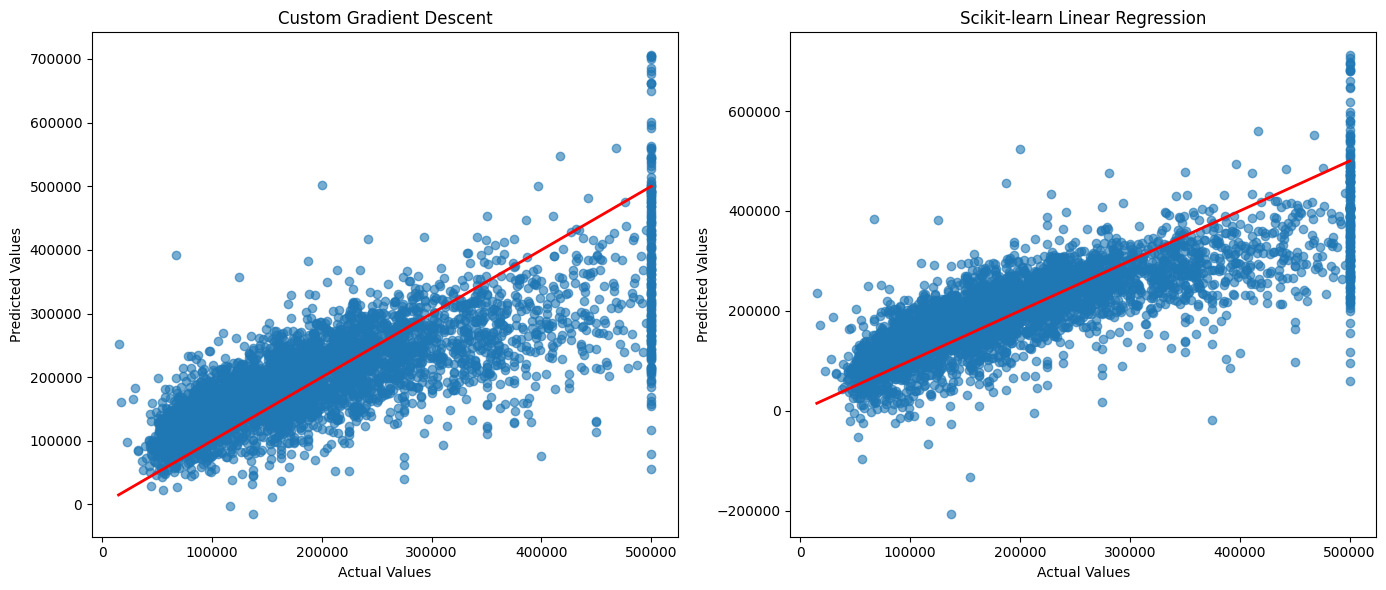

In [2]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

# -------------------------------
# Left: Custom Gradient Descent
# -------------------------------
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_custom, alpha=0.6)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Custom Gradient Descent")

# -------------------------------
# Right: Scikit-learn
# -------------------------------
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_sklearn, alpha=0.6)
plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Scikit-learn Linear Regression")

plt.tight_layout()
plt.show()